In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


### Imports

In [2]:
import itertools
import gc
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
%matplotlib inline

from tensorflow.keras import backend as K # Importing Keras backend (by default it is Tensorflow)
from tensorflow.keras.layers import Input, Dense # Layers to be used for building our model
from tensorflow.keras.models import Model # The class used to create a model
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
from tensorflow.random import set_seed

print("Tensorflow version " + tf.__version__)


Tensorflow version 2.19.0


### Data creation

**Task**: Element wise XOR betweeb binary vectors

**Data**:
- The data are represented as a numpy array of shape (train_size + test_size + val_size, vector_size * 2)
- Each row of the array contains a pair of vectors
- The first half of each row is the first vector
- The second half of each row is the second vector
- The true label is given by applying the XOR function between the 2 vectors

*The following is a safer way to create our data since we create all possible instances and shuffle from them avoiding possible repeated instances*

In [3]:
vector_size = 5 # The size of a vector.

# The data are represented as a numpy array of shape (train_size + test_size + val_size, vector * 2).
# Each row contains 2 vectors concatenated.
# Create all possible pairs of vectors
data=np.array(list(itertools.product([0, 1], repeat=vector_size * 2)))
np.random.seed(1402) # Define the seed in order to have reproducible data.
np.random.shuffle(data)


def split_data(data, train_size, val_size=16, test_size=16):
    x_train = data[:train_size, :] # train features
    y_train = x_train[:, :vector_size] ^ x_train[:, vector_size:] # train labels
    x_val = data[- (val_size + test_size):-test_size] # validation features
    y_val = x_val[:, :vector_size] ^ x_val[:, vector_size:] # validation labels
    x_test = data[-test_size:] # test features
    y_test = x_test[:, :vector_size] ^ x_test[:, vector_size:] # test labels
    return x_train, y_train, x_val, y_val, x_test, y_test


### Plotting results

In [4]:
def plot_history(hs, epochs):
    print()
    plt.style.use('dark_background')
    plt.rcParams['figure.figsize'] = [15, 8]
    plt.rcParams['font.size'] = 16
    plt.clf()
    for label in hs:
        plt.plot(hs[label].history['loss'], label='{0:s} train loss'.format(label))
        plt.plot(hs[label].history['val_loss'], label='{0:s} validation loss'.format(label))
    x_ticks = np.arange(0, epochs + 1, epochs / 10)
    x_ticks [0] += 1
    plt.xticks(x_ticks)
    plt.ylim((0, 1))
    plt.xlabel('Epochs')
    plt.ylabel('MSE')
    plt.legend()
    plt.show()


### Cleaning up

In [5]:
def clean_up(model):
    K.clear_session()
    del model
    gc.collect()


### Model creation

- We will use a Functional Model.
    - It is more flexible than the `Sequential` model but ...
    - We need to be careful with the sizes of the layers.
- The first layer should always be an `Input` layer where we specify the input of the model, e.g., the training data
- The other layers can be whatever we want and for each layer we must:
    - Define the input to the layer, i.e., another layer.
    - Define the number of units which also defines the output size.
        - The output size must be always equal to the number of units of the next layer.


In [6]:
def create_model(
    optimizer,
    hidden_layers=0,
    hidden_activation='linear',
    output_activation='linear'
):

    np.random.seed(1402) # Define the seed for numpy to have reproducible experiments.
    set_seed(1981) # Define the seed for Tensorflow to have reproducible experiments.

    # Define the input layer.
    input = Input(
        shape=(vector_size * 2,),
        name='Input'
    )

    x = input
    # Define the remaining hidden layers.
    for i in range(hidden_layers):
        x = Dense(
            units=vector_size * 2,
            kernel_initializer='uniform',
            activation=hidden_activation,
            name='Hidden-{0:d}'.format(i + 1)
        )(x)

    # Define the output layer.
    output = Dense(
        units=vector_size,
        kernel_initializer='uniform',
        activation=output_activation,
        name='Output'
    )(x)

    # Define the model and train it.
    model = Model(inputs=input, outputs=output)
    model.compile(optimizer=optimizer, loss='mse')
    return model

def train_model(
    model,
    train_data,
    train_labels,
    validation_data,
    epochs=6000,
    batch_size=1024
):
    hs = model.fit(
        x=train_data,
        y=train_labels,
        validation_data=validation_data,
        epochs=epochs,
        verbose=0,
        batch_size=batch_size
    )
    print('Finished training.')
    print('------------------')
    return hs


### Using just a few training data

In [7]:
x_train, y_train, x_val, y_val, x_test, y_test = split_data(data=data, train_size=256, val_size=32, test_size=32)

### Using SGD

In [8]:
# Using SGD
optimizer = SGD(learning_rate=0.01)
epochs = 5000

# Linear Regression

lr_small_model_sgd = create_model(
    optimizer=optimizer,
    hidden_layers=0,
    hidden_activation='linear',
    output_activation='linear'
)

lr_small_model_sgd.summary() # Print a description of the model.

lr_small_hs_sgd = train_model(
    model=lr_small_model_sgd,
    train_data=x_train,
    train_labels=y_train,
    validation_data=(x_val, y_val),
    epochs=epochs,
    batch_size=x_train.shape[0]
)

# Evaluate on test data and show all the results.
lr_small_eval_sgd = lr_small_model_sgd.evaluate(x_test, y_test, verbose=1)
clean_up(model=lr_small_model_sgd)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 5)              │            55 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55 (220.00 B)

 Trainable params: 55 (220.00 B)

 Non-trainable params: 0 (0.00 B)

Finished training.
------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.2678


### Linear Regression results

Train MSE     : 0.24237
Validation MSE: 0.25910
Test MSE      : 0.26783



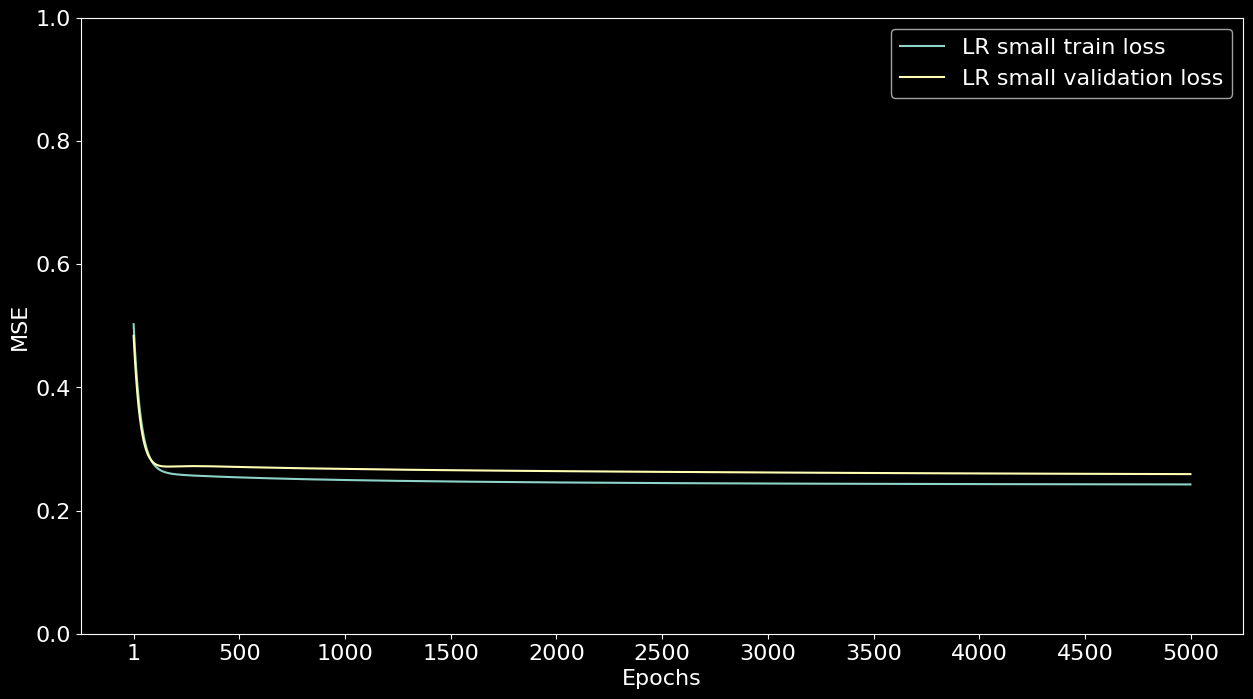

In [9]:
print("Train MSE     : {0:.5f}".format(lr_small_hs_sgd.history['loss'][-1]))
print("Validation MSE: {0:.5f}".format(lr_small_hs_sgd.history['val_loss'][-1]))
print("Test MSE      : {0:.5f}".format(lr_small_eval_sgd))

# Plot train and validation error per epoch.
plot = plot_history(hs={'LR small': lr_small_hs_sgd}, epochs=epochs)

In [10]:
# Using SGD
optimizer = SGD(learning_rate=0.01)
epochs = 5000

# Deep Regressor
dr_small_model_sgd = create_model(
    optimizer=optimizer,
    hidden_layers=1,
    hidden_activation='relu',
    output_activation='linear'
)

dr_small_model_sgd.summary() # Print a description of the model.

dr_small_hs_sgd = train_model(
    model=dr_small_model_sgd,
    train_data=x_train,
    train_labels=y_train,
    validation_data=(x_val, y_val),
    epochs=epochs,
    batch_size=x_train.shape[0]
)

dr_small_eval_sgd = dr_small_model_sgd.evaluate(x_test, y_test, verbose=1)
clean_up(model=dr_small_model_sgd)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden-1 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 5)              │            55 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165 (660.00 B)

 Trainable params: 165 (660.00 B)

 Non-trainable params: 0 (0.00 B)

Finished training.
------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.2504


### Linear Regressor vs. Deep Regressor

Train MSE     : 0.24479
Validation MSE: 0.24981
Test MSE      : 0.25045



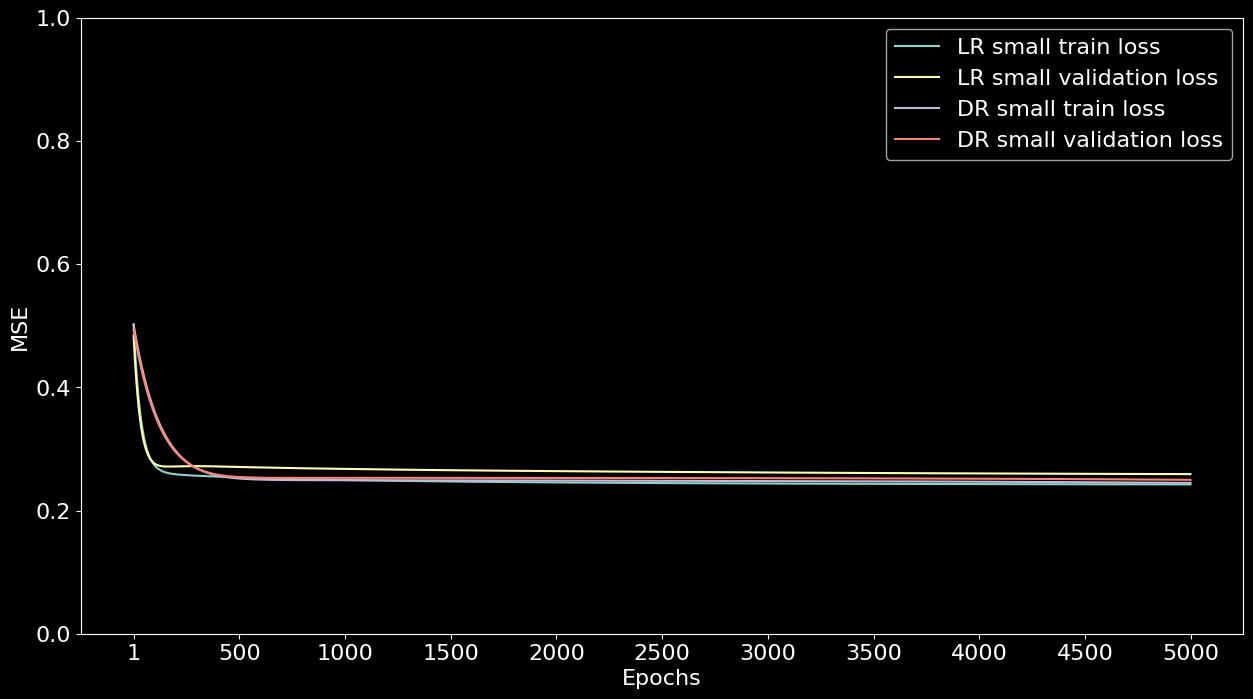

In [11]:
# Evaluate on test data and show all the results.
print("Train MSE     : {0:.5f}".format(dr_small_hs_sgd.history['loss'][-1]))
print("Validation MSE: {0:.5f}".format(dr_small_hs_sgd.history['val_loss'][-1]))
print("Test MSE      : {0:.5f}".format(dr_small_eval_sgd))

# Plot train and validation error per epoch.
plot_history(hs={'LR small': lr_small_hs_sgd, 'DR small': dr_small_hs_sgd}, epochs=epochs)

### Using SGD with momentum

In [12]:
# Using SGD with momentum
optimizer = SGD(learning_rate=0.01, momentum=0.9)
epochs = 5000

# Linear Regression
lr_small_model_sgd_momentum = create_model(
    optimizer=optimizer,
    hidden_layers=0,
    hidden_activation='linear',
    output_activation='linear'
)

lr_small_model_sgd_momentum.summary() # Print a description of the model.

lr_small_hs_sgd_momentum = train_model(
    model=lr_small_model_sgd_momentum,
    train_data=x_train,
    train_labels=y_train,
    validation_data=(x_val, y_val),
    epochs=epochs,
    batch_size=x_train.shape[0]
)

# Evaluate on test data and show all the results.
lr_small_eval_sgd_momentum = lr_small_model_sgd_momentum.evaluate(x_test, y_test, verbose=1)
clean_up(model=lr_small_model_sgd_momentum)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 5)              │            55 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55 (220.00 B)

 Trainable params: 55 (220.00 B)

 Non-trainable params: 0 (0.00 B)

Finished training.
------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.2678


### Show Linear Regression results

Train MSE     : 0.24168
Validation MSE: 0.25643
Test MSE      : 0.26778



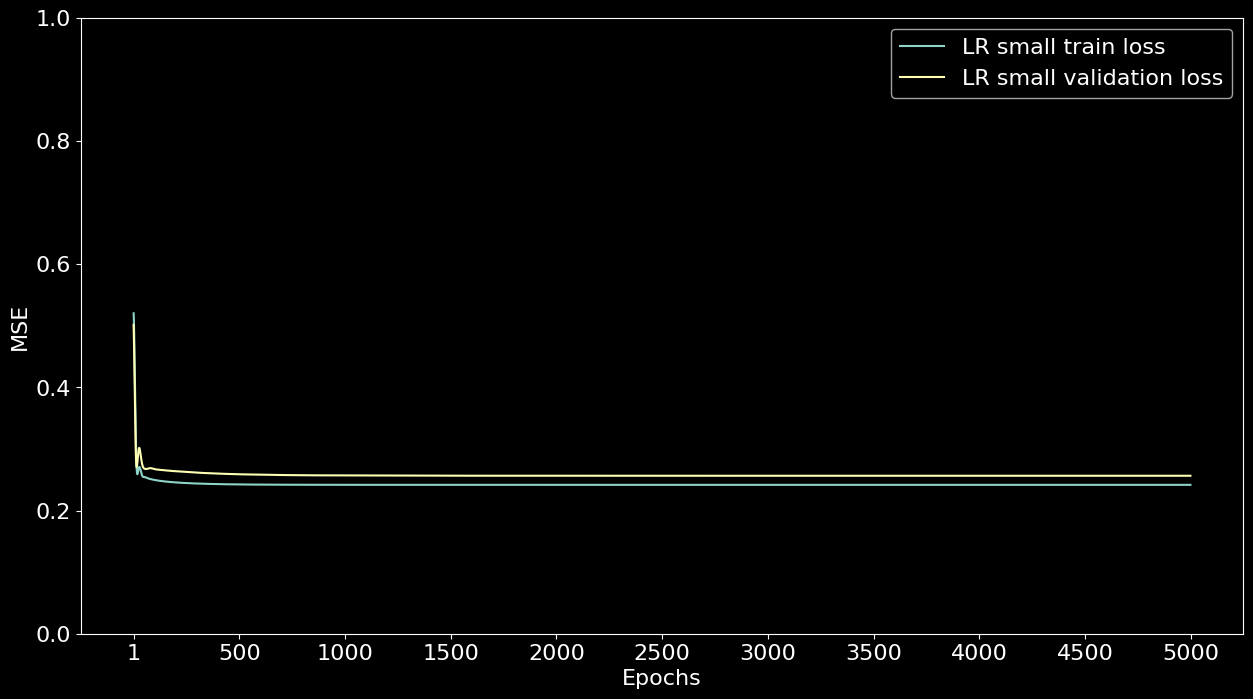

In [13]:
print("Train MSE     : {0:.5f}".format(lr_small_hs_sgd_momentum.history['loss'][-1]))
print("Validation MSE: {0:.5f}".format(lr_small_hs_sgd_momentum.history['val_loss'][-1]))
print("Test MSE      : {0:.5f}".format(lr_small_eval_sgd_momentum))

# Plot train and validation error per epoch.
plot = plot_history(hs={'LR small': lr_small_hs_sgd_momentum}, epochs=epochs)

In [14]:
# Using SGD with momentum
optimizer = SGD(learning_rate=0.01, momentum=0.9)
epochs = 5000

# Deep Regressor
dr_small_model_sgd_momentum = create_model(
    optimizer=optimizer,
    hidden_layers=1,
    hidden_activation='relu',
    output_activation='linear'
)

dr_small_model_sgd_momentum.summary() # Print a description of the model.

dr_small_hs_sgd_momentum = train_model(
    model=dr_small_model_sgd_momentum,
    train_data=x_train,
    train_labels=y_train,
    validation_data=(x_val, y_val),
    epochs=epochs,
    batch_size=x_train.shape[0]
)

dr_small_eval_sgd_momentum = dr_small_model_sgd_momentum.evaluate(x_test, y_test, verbose=1)
clean_up(model=dr_small_model_sgd_momentum)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden-1 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 5)              │            55 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165 (660.00 B)

 Trainable params: 165 (660.00 B)

 Non-trainable params: 0 (0.00 B)

Finished training.
------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0465


### Linear Regressor vs. Deep Regressor

Train MSE     : 0.02945
Validation MSE: 0.03667
Test MSE      : 0.04652



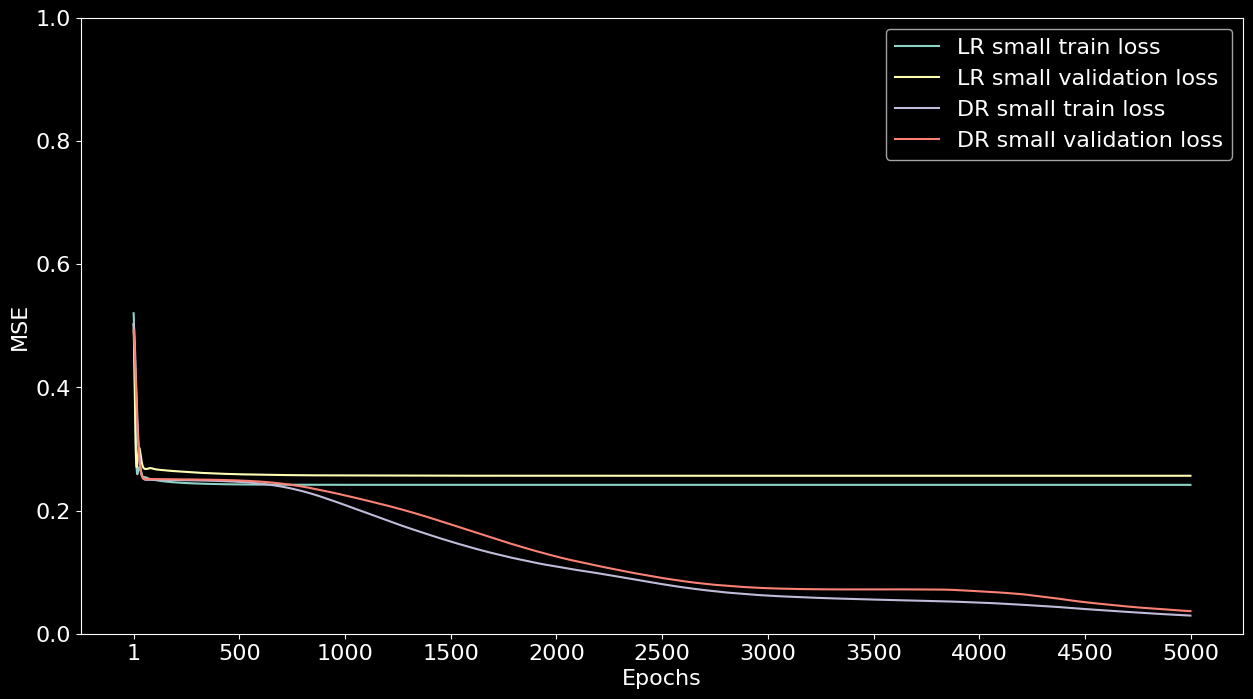

In [15]:
# Evaluate on test data and show all the results.
print("Train MSE     : {0:.5f}".format(dr_small_hs_sgd_momentum.history['loss'][-1]))
print("Validation MSE: {0:.5f}".format(dr_small_hs_sgd_momentum.history['val_loss'][-1]))
print("Test MSE      : {0:.5f}".format(dr_small_eval_sgd_momentum))

# Plot train and validation error per epoch.
plot_history(hs={'LR small': lr_small_hs_sgd_momentum, 'DR small': dr_small_hs_sgd_momentum}, epochs=epochs)

### Using SGD with Nesterov Momentum

In [16]:
# Using SGD with Nesterov momentum
optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
epochs = 5000

# Linear Regression
lr_small_model_sgd_nesterov = create_model(
    optimizer=optimizer,
    hidden_layers=0,
    hidden_activation='linear',
    output_activation='linear'
)

lr_small_model_sgd_nesterov.summary() # Print a description of the model.

lr_small_hs_sgd_nesterov = train_model(
    model=lr_small_model_sgd_nesterov,
    train_data=x_train,
    train_labels=y_train,
    validation_data=(x_val, y_val),
    epochs=epochs,
    batch_size=x_train.shape[0]
)

# Evaluate on test data and show all the results.
lr_small_eval_sgd_nesterov = lr_small_model_sgd_nesterov.evaluate(x_test, y_test, verbose=1)
clean_up(model=lr_small_model_sgd_nesterov)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 5)              │            55 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55 (220.00 B)

 Trainable params: 55 (220.00 B)

 Non-trainable params: 0 (0.00 B)

Finished training.
------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.2678


### Show Linear Regression results

Train MSE     : 0.24168
Validation MSE: 0.25643
Test MSE      : 0.26778



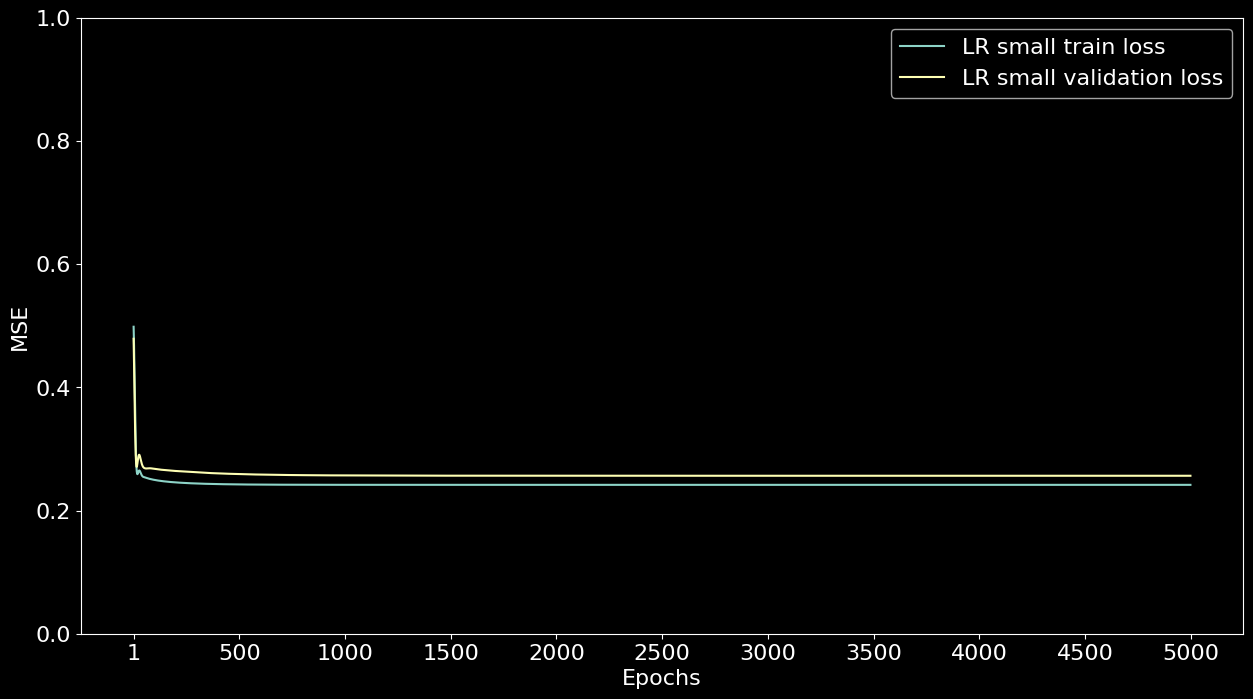

In [17]:
print("Train MSE     : {0:.5f}".format(lr_small_hs_sgd_nesterov.history['loss'][-1]))
print("Validation MSE: {0:.5f}".format(lr_small_hs_sgd_nesterov.history['val_loss'][-1]))
print("Test MSE      : {0:.5f}".format(lr_small_eval_sgd_nesterov))

# Plot train and validation error per epoch.
plot = plot_history(hs={'LR small': lr_small_hs_sgd_nesterov}, epochs=epochs)

In [18]:
# Using SGD with Nesterov momentum
optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
epochs = 5000

# Deep Regressor
dr_small_model_sgd_nesterov = create_model(
    optimizer=optimizer,
    hidden_layers=1,
    hidden_activation='relu',
    output_activation='linear'
)

dr_small_model_sgd_nesterov.summary() # Print a description of the model

dr_small_hs_sgd_nesterov = train_model(
    model=dr_small_model_sgd_nesterov,
    train_data=x_train,
    train_labels=y_train,
    validation_data=(x_val, y_val),
    epochs=epochs,
    batch_size=x_train.shape[0]
)

dr_small_eval_sgd_nesterov = dr_small_model_sgd_nesterov.evaluate(x_test, y_test, verbose=1)
clean_up(model=dr_small_model_sgd_nesterov)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden-1 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 5)              │            55 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165 (660.00 B)

 Trainable params: 165 (660.00 B)

 Non-trainable params: 0 (0.00 B)

Finished training.
------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.1046


### Linear Regressor vs. Deep Regressor

Train MSE     : 0.09052
Validation MSE: 0.09328
Test MSE      : 0.10455



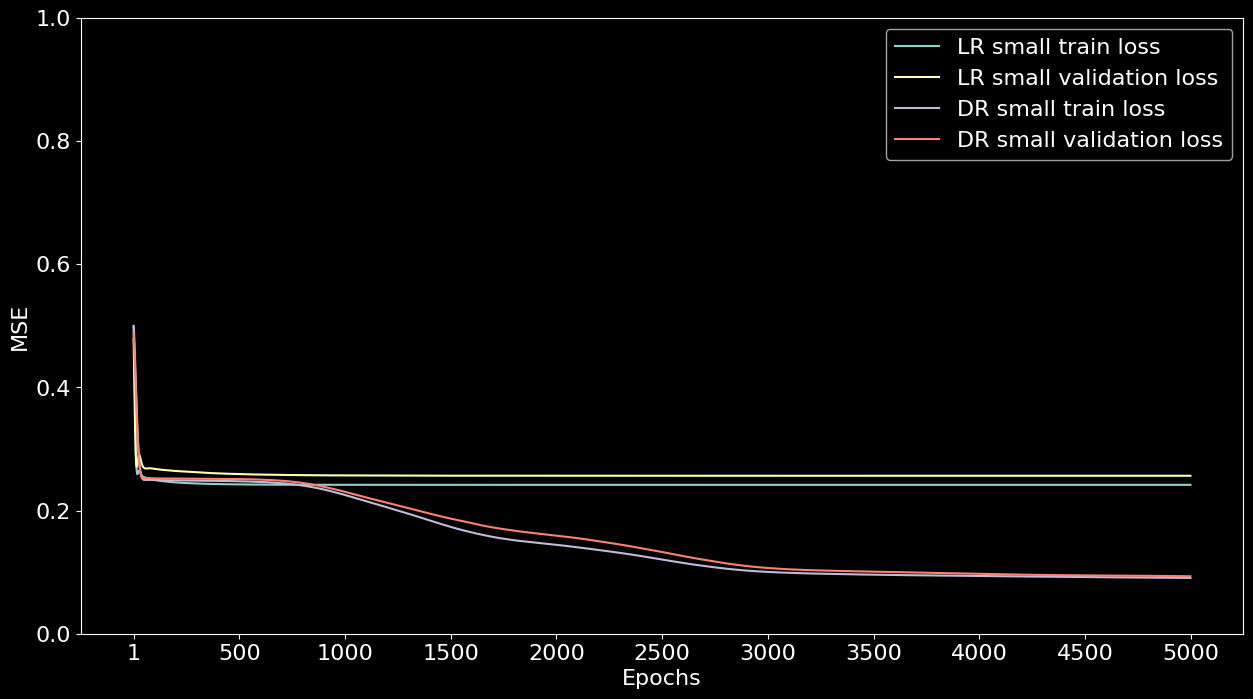

In [19]:
# Evaluate on test data and show all the results.
print("Train MSE     : {0:.5f}".format(dr_small_hs_sgd_nesterov.history['loss'][-1]))
print("Validation MSE: {0:.5f}".format(dr_small_hs_sgd_nesterov.history['val_loss'][-1]))
print("Test MSE      : {0:.5f}".format(dr_small_eval_sgd_nesterov))

# Plot train and validation error per epoch.
plot_history(
    hs={
        'LR small': lr_small_hs_sgd_nesterov,
        'DR small': dr_small_hs_sgd_nesterov
    },
    epochs=epochs)

### Using all the training data

In [20]:
x_train, y_train, x_val, y_val, x_test, y_test = split_data(data=data, train_size=data.shape[0], val_size=32, test_size=32)

### Using SGD with Nesterov Momentum

In [21]:
# Using SGD with Nesterov momentum
optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
epochs = 10000

# Linear Regression
lr_model_sgd_nesterov = create_model(
    optimizer=optimizer,
    hidden_layers=0,
    hidden_activation='linear',
    output_activation='linear'
)

lr_model_sgd_nesterov.summary() # Print a description of the model

lr_hs_sgd_nesterov = train_model(
    model=lr_model_sgd_nesterov,
    train_data=x_train,
    train_labels=y_train,
    validation_data=(x_val, y_val),
    epochs=epochs,
    batch_size=x_train.shape[0]
)

# Evaluate on test data and show all the results.
lr_eval_sgd_nesterov = lr_model_sgd_nesterov.evaluate(x_test, y_test, verbose=1)
clean_up(model=lr_model_sgd_nesterov)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 5)              │            55 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55 (220.00 B)

 Trainable params: 55 (220.00 B)

 Non-trainable params: 0 (0.00 B)

Finished training.
------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.2500


### Show Linear Regression results

Train MSE     : 0.25000
Validation MSE: 0.25000
Test MSE      : 0.25000



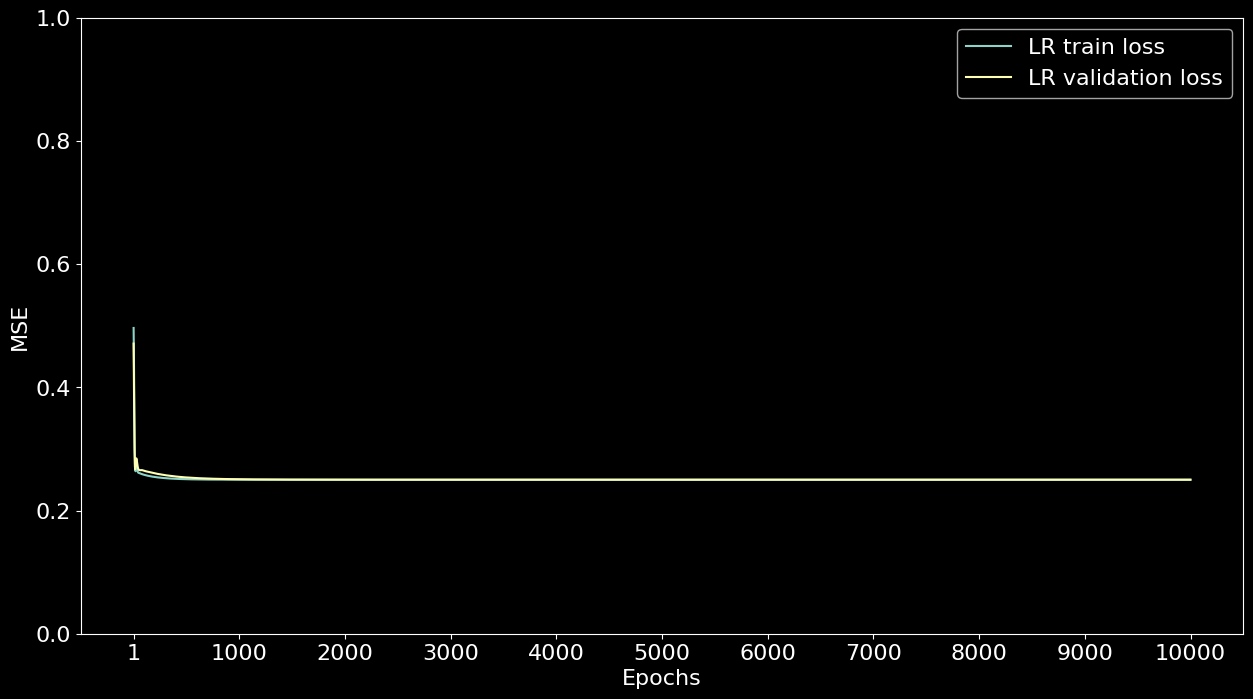

In [22]:
print("Train MSE     : {0:.5f}".format(lr_hs_sgd_nesterov.history['loss'][-1]))
print("Validation MSE: {0:.5f}".format(lr_hs_sgd_nesterov.history['val_loss'][-1]))
print("Test MSE      : {0:.5f}".format(lr_eval_sgd_nesterov))

# Plot train and validation error per epoch.
plot = plot_history(hs={'LR': lr_hs_sgd_nesterov}, epochs=epochs)

In [23]:
# Using SGD with Nesterov momentum
optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
epochs = 10000

# Deep Regressor
dr_model_sgd_nesterov = create_model(
    optimizer=optimizer,
    hidden_layers=1,
    hidden_activation='relu',
    output_activation='linear'
)

dr_model_sgd_nesterov.summary() # Print a description of the model

dr_hs_sgd_nesterov = train_model(
    model=dr_model_sgd_nesterov,
    train_data=x_train,
    train_labels=y_train,
    validation_data=(x_val, y_val),
    epochs=epochs,
    batch_size=x_train.shape[0]
)

dr_eval_sgd_nesterov = dr_model_sgd_nesterov.evaluate(x_test, y_test, verbose=1)
clean_up(model=dr_model_sgd_nesterov)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden-1 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 5)              │            55 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165 (660.00 B)

 Trainable params: 165 (660.00 B)

 Non-trainable params: 0 (0.00 B)

Finished training.
------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0315


### Linear Regressor vs. Deep Regressor

Train MSE     : 0.03333
Validation MSE: 0.04034
Test MSE      : 0.03148



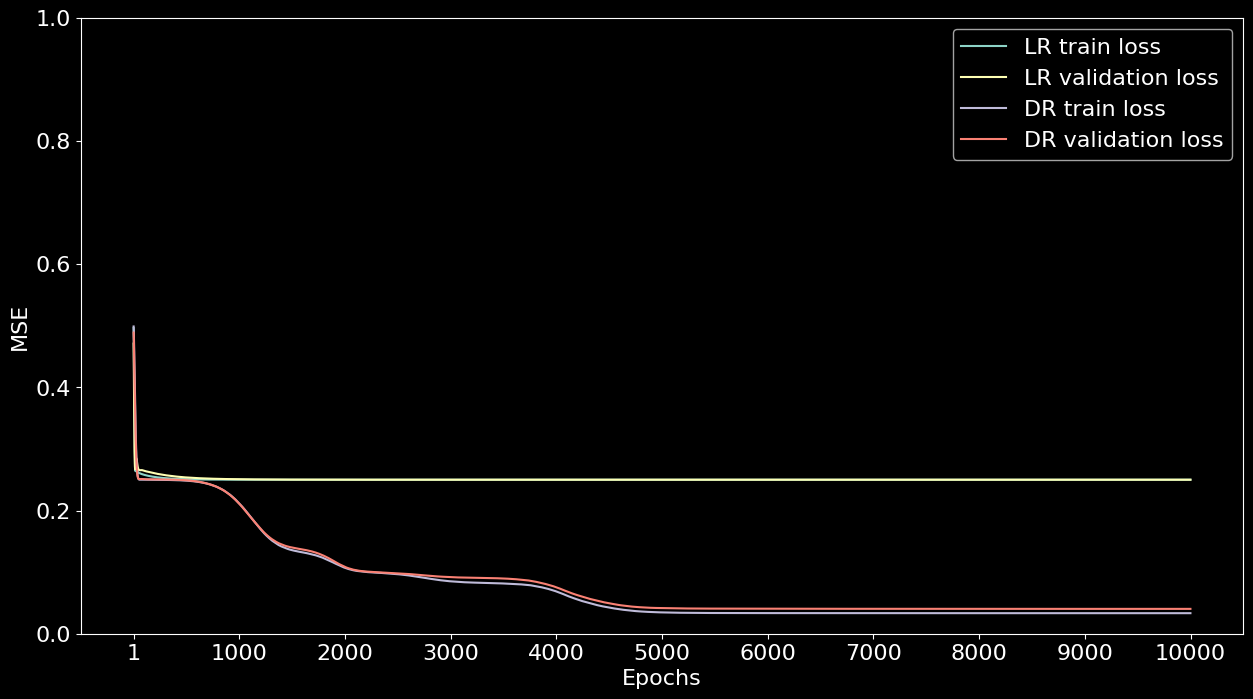

In [24]:
# Evaluate on test data and show all the results.
print("Train MSE     : {0:.5f}".format(dr_hs_sgd_nesterov.history['loss'][-1]))
print("Validation MSE: {0:.5f}".format(dr_hs_sgd_nesterov.history['val_loss'][-1]))
print("Test MSE      : {0:.5f}".format(dr_eval_sgd_nesterov))

# Plot train and validation error per epoch.
plot_history(
    hs={
        'LR': lr_hs_sgd_nesterov,
        'DR': dr_hs_sgd_nesterov
    },
    epochs=epochs)

### Using SGD with Nesterov Momentum and increased learning rate (η)

In [25]:
# Using SGD with Nesterov momentum and increased learning rate
optimizer = SGD(learning_rate=0.5, momentum=0.9, nesterov=True)
epochs = 10000

# Deep Regressor
dr_model_sgd_nesterov_large_rate = create_model(
    optimizer=optimizer,
    hidden_layers=1,
    hidden_activation='relu',
    output_activation='linear'
)

dr_model_sgd_nesterov_large_rate.summary() # Print a description of the model

dr_hs_sgd_nesterov_large_rate = train_model(
    model=dr_model_sgd_nesterov_large_rate,
    train_data=x_train,
    train_labels=y_train,
    validation_data=(x_val, y_val),
    epochs=epochs,
    batch_size=x_train.shape[0]
)

dr_eval_sgd_nesterov_large_rate = dr_model_sgd_nesterov_large_rate.evaluate(x_test, y_test, verbose=1)
clean_up(model=dr_model_sgd_nesterov_large_rate)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden-1 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 5)              │            55 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165 (660.00 B)

 Trainable params: 165 (660.00 B)

 Non-trainable params: 0 (0.00 B)

Finished training.
------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.1715


### Deep Regressor (η = 0.01) vs. Deep Regressor (η = 0.5)

Train MSE     : 0.18333
Validation MSE: 0.19165
Test MSE      : 0.17154



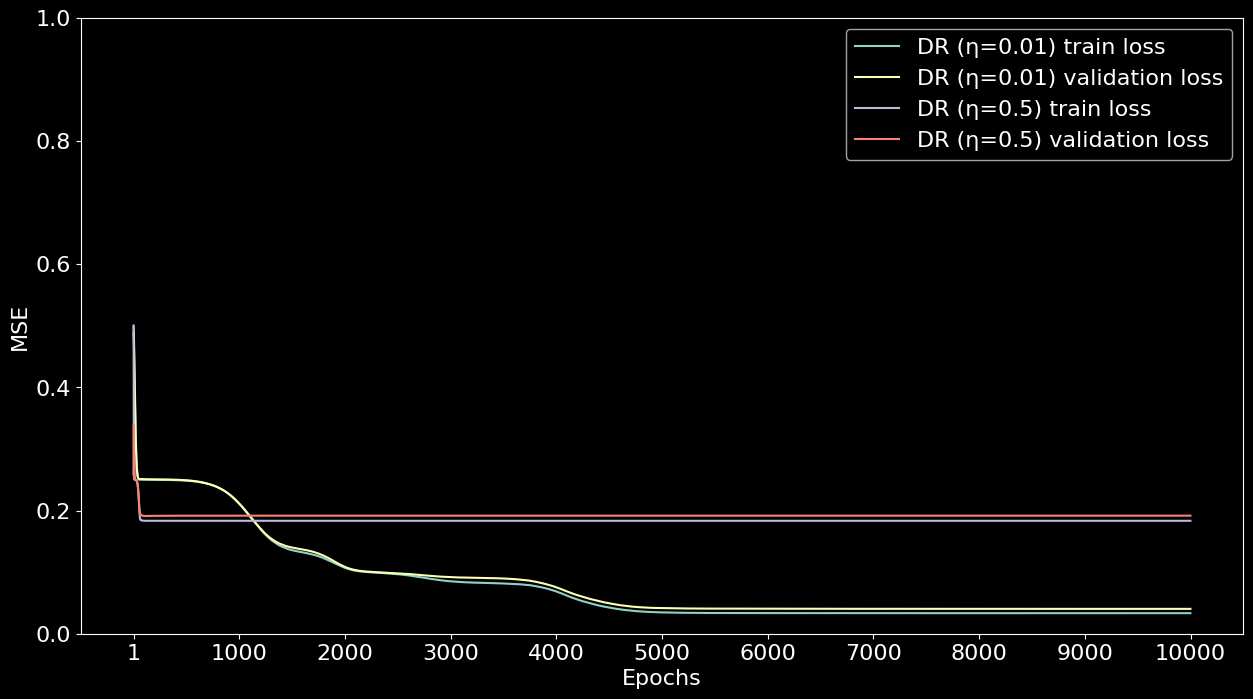

In [30]:
# Evaluate on test data and show all the results.
print("Train MSE     : {0:.5f}".format(dr_hs_sgd_nesterov_large_rate.history['loss'][-1]))
print("Validation MSE: {0:.5f}".format(dr_hs_sgd_nesterov_large_rate.history['val_loss'][-1]))
print("Test MSE      : {0:.5f}".format(dr_eval_sgd_nesterov_large_rate))

# Plot train and validation error per epoch.
plot_history(
    hs={
        'DR (η=0.01)': dr_hs_sgd_nesterov,
        'DR (η=0.5)': dr_hs_sgd_nesterov_large_rate
    },
    epochs=epochs)

### Using Adam

In [27]:
# Using Adam
optimizer = Adam()
epochs = 10000

# Deep Regressor
dr_model_adam = create_model(
    optimizer=optimizer,
    hidden_layers=1,
    hidden_activation='relu',
    output_activation='linear'
)

dr_model_adam.summary() # Print a description of the model

dr_hs_adam = train_model(
    model=dr_model_adam,
    train_data=x_train,
    train_labels=y_train,
    validation_data=(x_val, y_val),
    epochs=epochs,
    batch_size=x_train.shape[0]
)

dr_eval_adam = dr_model_adam.evaluate(x_test, y_test, verbose=1)
clean_up(model=dr_model_adam)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden-1 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 5)              │            55 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165 (660.00 B)

 Trainable params: 165 (660.00 B)

 Non-trainable params: 0 (0.00 B)

Finished training.
------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 2.9976e-07


### Deep Regressor (SGD, η = 0.5) vs. Deep Regressor (Adam)

Train MSE     : 0.00000
Validation MSE: 0.00000
Test MSE      : 0.00000



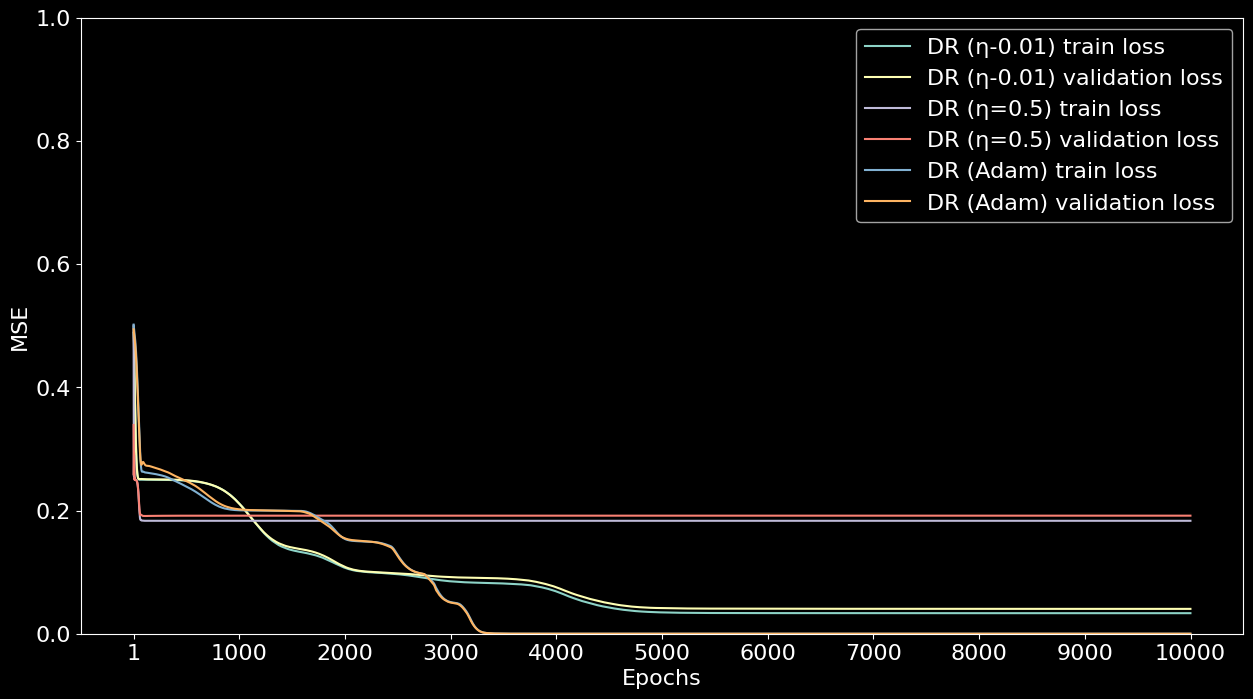

In [29]:
# Evaluate on test data and show all the results.
print("Train MSE     : {0:.5f}".format(dr_hs_adam.history['loss'][-1]))
print("Validation MSE: {0:.5f}".format(dr_hs_adam.history['val_loss'][-1]))
print("Test MSE      : {0:.5f}".format(dr_eval_adam))

# Plot train and validation error per epoch.
plot_history(
    hs={
        'DR (η-0.01)': dr_hs_sgd_nesterov,
        'DR (η=0.5)': dr_hs_sgd_nesterov_large_rate,
        'DR (Adam)': dr_hs_adam
    },
    epochs=epochs)